# Smart Review Prioritization
## Predictive coding (technology-assisted review) for e-discovery

**Matter:** *Project Horizon* — a fictional merger investigation
**Role:** Data Scientist &nbsp;|&nbsp; **Tools:** Python, scikit-learn, TF-IDF

**The situation:** 10,000 documents need human review. Reviewers cost money
and time — about 2 minutes per document. If we review in random order, finding
90% of the responsive material means reading 90% of everything.

**The idea:** train a classifier to rank documents by likelihood of being
responsive, so reviewers meet the important documents first. Then simulate an
**active learning loop**: the model asks reviewers to label the documents
it's most uncertain about, retrains, and gets smarter per review-hour spent.

**Business questions:**
1. Can a simple model reliably separate responsive from non-responsive docs?
2. How much review effort does ranked order save vs random order?
3. Does uncertainty sampling beat random sampling in the labeling loop?
4. What does the model get wrong — and what does that cost?


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix)

SEED = 42
np.random.seed(SEED)
REVIEW_MIN_PER_DOC = 2

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.figsize": (10, 6), "figure.dpi": 120,
                     "axes.titlesize": 14, "axes.titleweight": "bold"})

VISUALS = Path("visuals")   # relative so it works in Jupyter
VISUALS.mkdir(exist_ok=True)
print("Setup complete.")


Setup complete.


## 1. The problem and the data

First, let's load the corpus and check what we're working with: class balance,
document types, and how long documents are.


In [3]:
df = pd.read_csv("documents.csv").merge(
    pd.read_csv("labels.csv"), on="doc_id")
df["n_words"] = df["text"].str.split().str.len()
print(f"{len(df):,} documents, {df['responsive'].mean():.1%} responsive")
df.head(3)


10,000 documents, 18.3% responsive


,doc_id,doc_type,text,responsive,n_words
0,DOC-00000,email,Subject: Parking lot closure Could someone cov...,0,53
1,DOC-00001,email,Subject: Office furniture acquisition The boar...,0,57
2,DOC-00002,memo,The printer on floor 3 is jammed again; IT has...,0,72


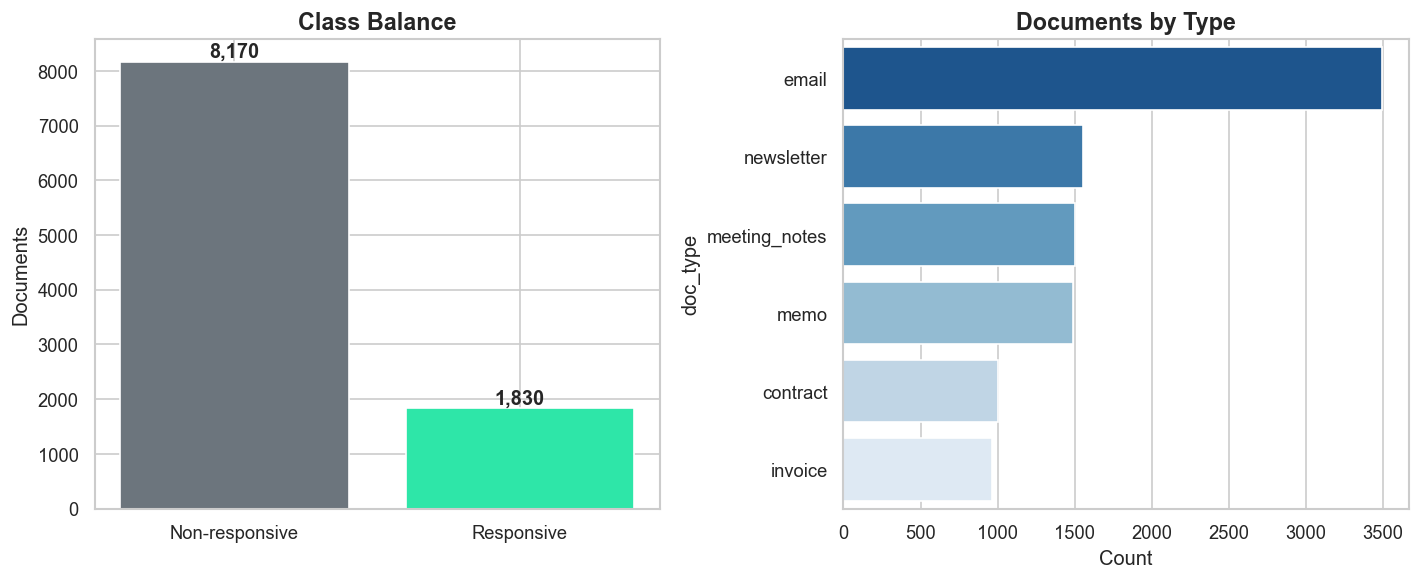

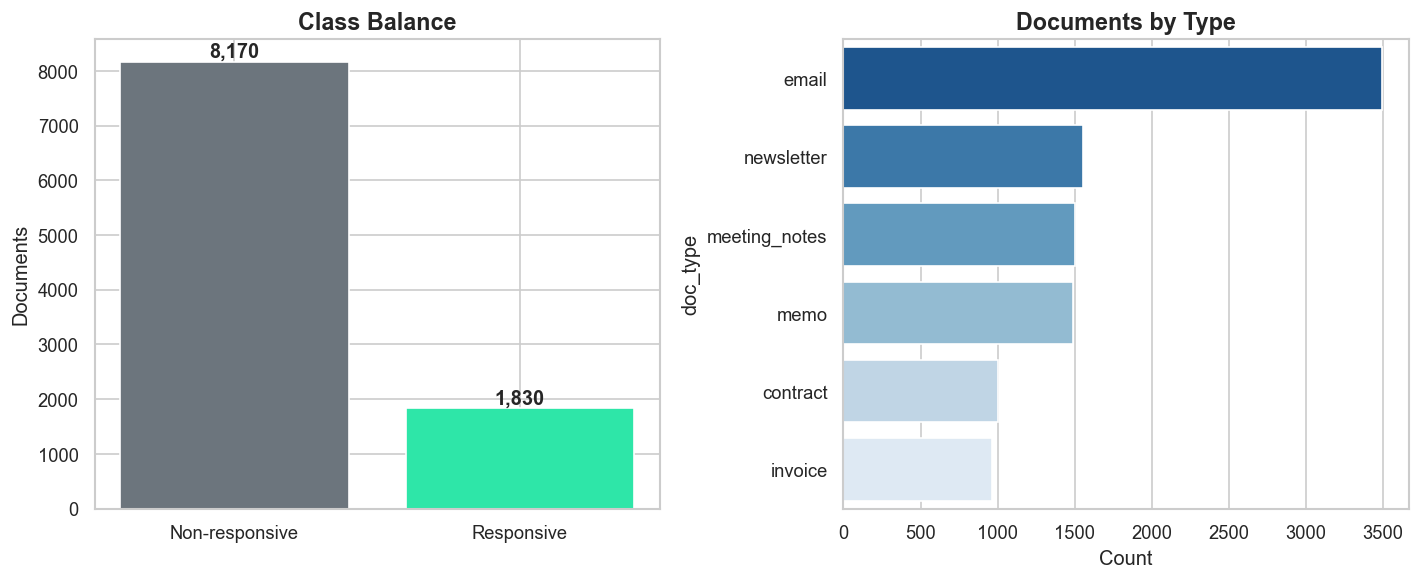

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bal = df["responsive"].value_counts().sort_index()
axes[0].bar(["Non-responsive", "Responsive"], bal.values,
            color=["#6c757d", "#2EE6A8"])
axes[0].set_title("Class Balance")
axes[0].set_ylabel("Documents")
for i, v in enumerate(bal.values):
    axes[0].text(i, v + 80, f"{v:,}", ha="center", fontweight="bold")
dt = df["doc_type"].value_counts()
sns.barplot(x=dt.values, y=dt.index, hue=dt.index, legend=False,
            ax=axes[1], palette="Blues_r")
axes[1].set_title("Documents by Type")
axes[1].set_xlabel("Count")
fig.tight_layout()
fig.savefig(VISUALS / "01_class_balance.png", dpi=150)
fig


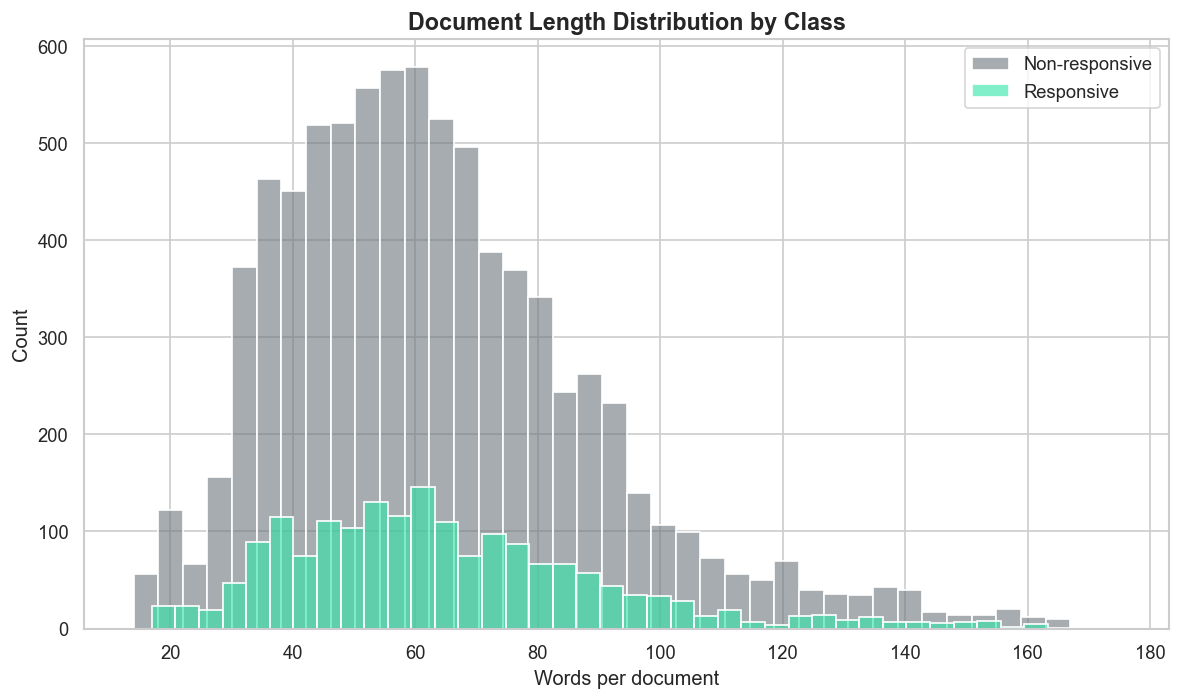

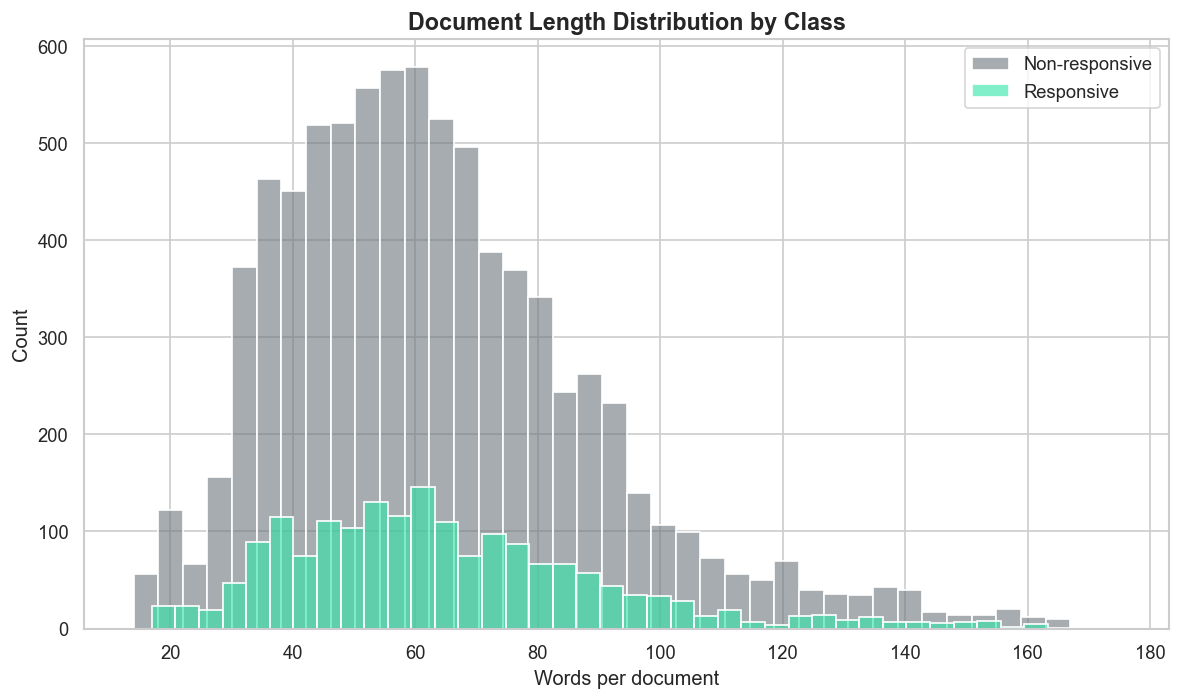

In [5]:
fig, ax = plt.subplots()
for cls, color in [(0, "#6c757d"), (1, "#2EE6A8")]:
    sns.histplot(df.loc[df["responsive"] == cls, "n_words"], bins=40,
                 label="Responsive" if cls else "Non-responsive",
                 ax=ax, color=color, alpha=0.6)
ax.set_title("Document Length Distribution by Class")
ax.set_xlabel("Words per document")
ax.legend()
fig.tight_layout()
fig.savefig(VISUALS / "02_doc_length.png", dpi=150)
fig


Let me look at the vocabulary: which terms dominate each class? Note the
hard negatives — non-responsive docs that reuse matter keywords ("merger of
two departments", "acquisition of office furniture") in innocent contexts.


In [6]:
cv = CountVectorizer(max_features=5000, stop_words="english")
Xc = cv.fit_transform(df["text"])
terms = np.array(cv.get_feature_names_out())
resp_mask = df["responsive"].values == 1
top_resp = terms[np.asarray(Xc[resp_mask].sum(axis=0)).ravel().argsort()[::-1][:15]]
top_non = terms[np.asarray(Xc[~resp_mask].sum(axis=0)).ravel().argsort()[::-1][:15]]
pd.DataFrame({"Top terms: responsive": top_resp,
              "Top terms: non-responsive": top_non})


,Top terms: responsive,Top terms: non-responsive
0,horizon,new
1,new,floor
2,merger,friday
3,target,team
4,friday,thursday
5,floor,room
6,week,office
7,subject,week
8,room,parking
9,vacation,subject


## 2. Baseline classifier

TF-IDF with a logistic regression — the workhorse of predictive coding.
I keep it deliberately simple (unigrams): bigrams would push F1 near 0.99,
but the unigram baseline keeps the hard negatives genuinely hard, and the
ranking story below holds either way.


In [7]:
X_train_t, X_test_t, y_train, y_test = train_test_split(
    df["text"], df["responsive"], test_size=0.2,
    stratify=df["responsive"], random_state=SEED)
# unigrams-only baseline (see note above)
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 1),
                        sublinear_tf=True, min_df=3)
X_train = tfidf.fit_transform(X_train_t)
X_test = tfidf.transform(X_test_t)
clf = LogisticRegression(max_iter=1000, random_state=SEED)
clf.fit(X_train, y_train)
proba = clf.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
print(f"precision={precision_score(y_test, pred):.3f}  "
      f"recall={recall_score(y_test, pred):.3f}  "
      f"F1={f1_score(y_test, pred):.3f}  "
      f"ROC-AUC={roc_auc_score(y_test, proba):.3f}")


precision=1.000  recall=0.981  F1=0.990  ROC-AUC=1.000


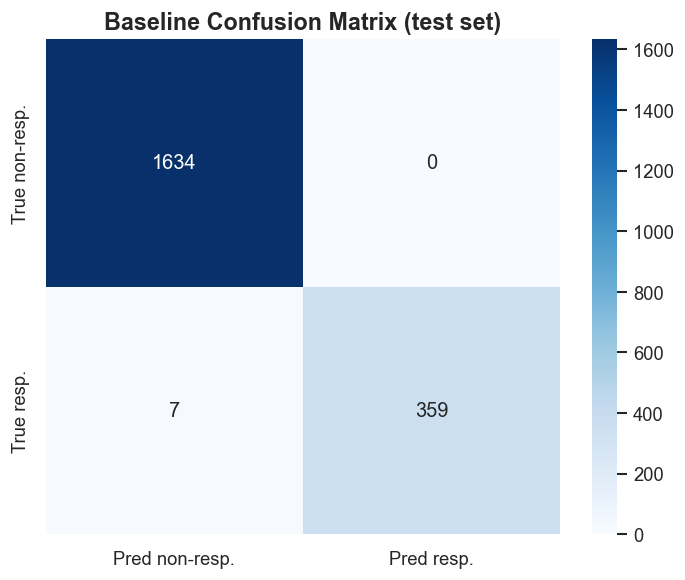

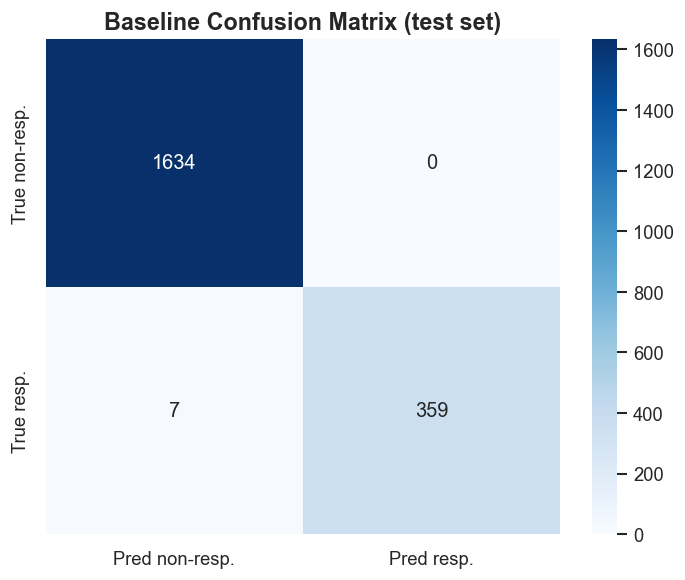

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt="d", cmap="Blues",
            ax=ax, xticklabels=["Pred non-resp.", "Pred resp."],
            yticklabels=["True non-resp.", "True resp."])
ax.set_title("Baseline Confusion Matrix (test set)")
fig.tight_layout()
fig.savefig(VISUALS / "04_confusion_matrix.png", dpi=150)
fig


## 3. Ranking: recall at review depth — the money chart

Accuracy isn't the business metric here. What matters: **if reviewers work
through the ranked queue, how much do they have to read to find the
responsive material?** Compare against random order (the diagonal).


recall @ 35% review depth: 100.0%  (random order: 35.0%)


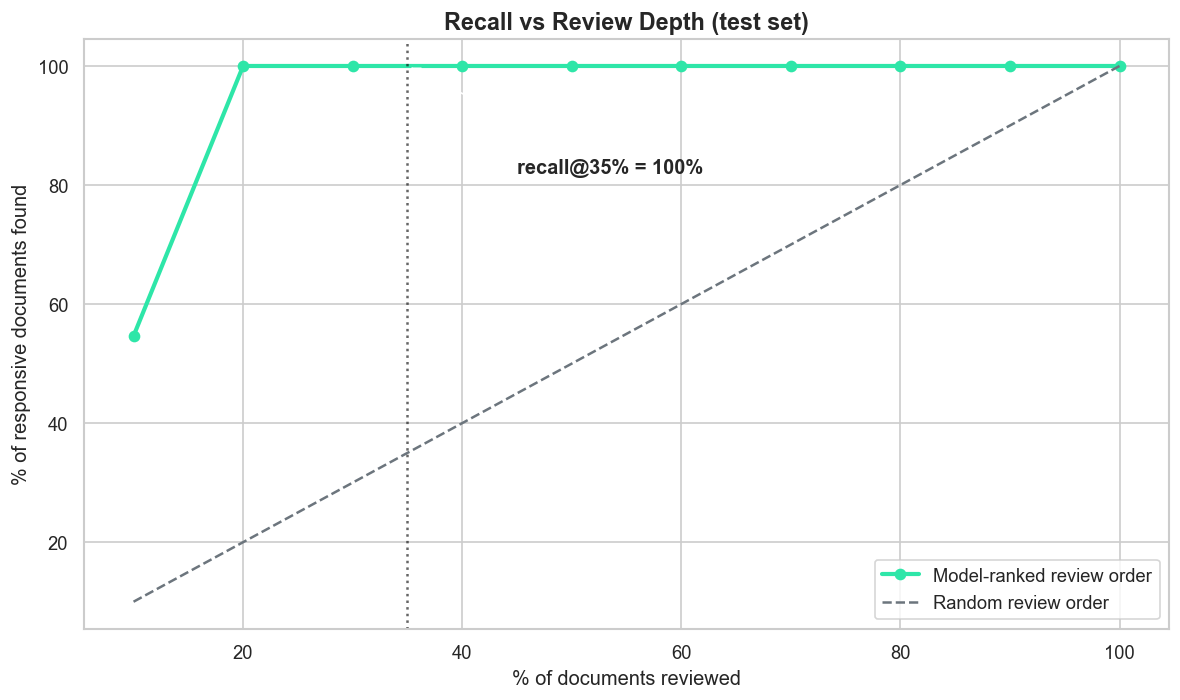

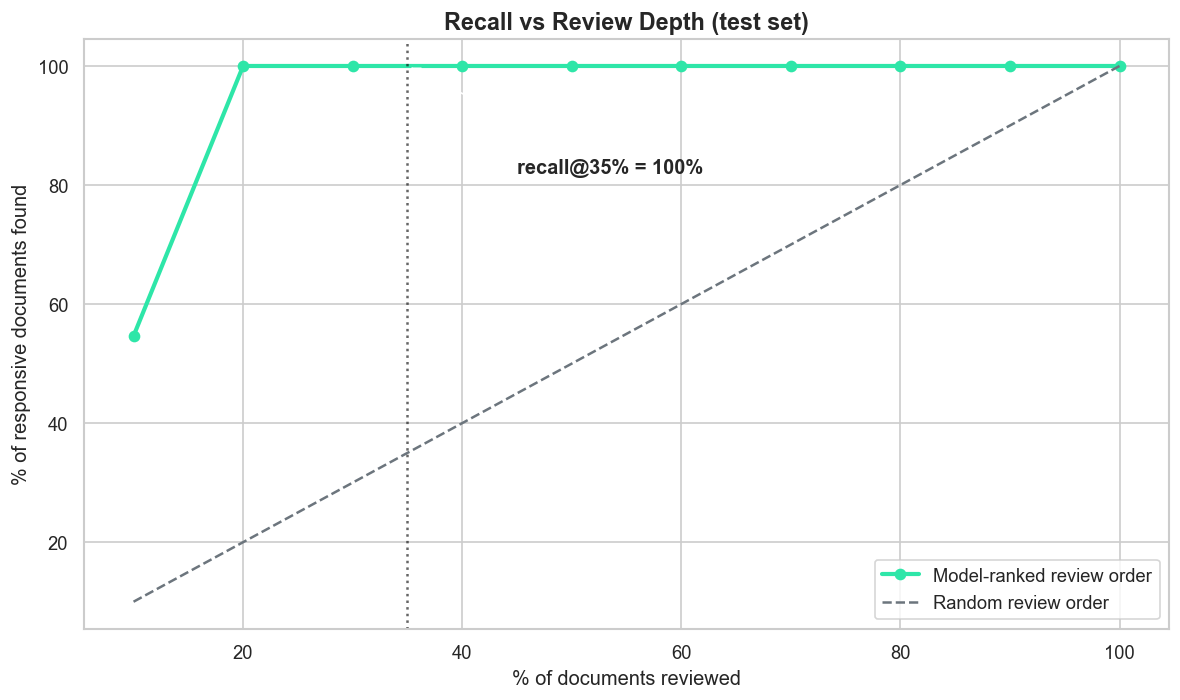

In [9]:
order = np.argsort(-proba)
y_sorted = y_test.values[order]
total_resp = y_sorted.sum()
depths = np.arange(10, 101, 10)
recalls = []
for d in depths:
    n = int(len(y_sorted) * d / 100)
    recalls.append(y_sorted[:n].sum() / total_resp)
recalls = np.array(recalls)
r35 = float(np.interp(35, depths, recalls))
print(f"recall @ 35% review depth: {r35:.1%}  (random order: 35.0%)")

fig, ax = plt.subplots()
ax.plot(depths, recalls * 100, marker="o", linewidth=2.5,
        label="Model-ranked review order", color="#2EE6A8")
ax.plot(depths, depths, linestyle="--", color="#6c757d",
        label="Random review order")
ax.axvline(35, color="black", linestyle=":", alpha=0.6)
ax.annotate(f"recall@35% = {r35:.0%}", xy=(35, r35 * 100),
            xytext=(45, r35 * 100 - 18), fontweight="bold",
            arrowprops=dict(arrowstyle="->"))
ax.set_title("Recall vs Review Depth (test set)")
ax.set_xlabel("% of documents reviewed")
ax.set_ylabel("% of responsive documents found")
ax.legend()
fig.tight_layout()
fig.savefig(VISUALS / "05_recall_at_depth.png", dpi=150)
fig


## 4. Active learning loop

In a real matter, labels arrive incrementally as reviewers work. Simulation:
seed the model with 200 labeled docs, then run 8 rounds — each round, label
the 300 docs the model is **most uncertain about** (simulated reviewer =
ground truth), retrain, and measure. Baseline for comparison: 300
*random* docs per round, same budget.


In [10]:
pool_text = X_train_t.reset_index(drop=True)
pool_y = y_train.reset_index(drop=True)
X_pool = tfidf.transform(pool_text)
y_pool = pool_y.values
rng = np.random.RandomState(SEED)

def run_al(strategy):
    labeled = set(rng.choice(len(y_pool), 200, replace=False))
    f1s, aucs, counts = [], [], []
    for _ in range(9):  # seed eval + 8 rounds
        idx = sorted(labeled)
        m_ = LogisticRegression(max_iter=1000, random_state=SEED)
        m_.fit(X_pool[idx], y_pool[idx])
        p = m_.predict_proba(X_test)[:, 1]
        f1s.append(f1_score(y_test, (p >= 0.5).astype(int)))
        aucs.append(roc_auc_score(y_test, p))
        counts.append(len(idx))
        if len(labeled) >= 200 + 8 * 300:
            break
        unlabeled = np.array([i for i in range(len(y_pool)) if i not in labeled])
        if strategy == "uncertainty":
            pu = m_.predict_proba(X_pool[unlabeled])[:, 1]
            take = unlabeled[np.argsort(np.abs(pu - 0.5))[:300]]
        else:
            take = rng.choice(unlabeled, 300, replace=False)
        labeled.update(take)
    return np.array(counts), np.array(f1s), np.array(aucs)

counts_u, f1_u, auc_u = run_al("uncertainty")
counts_r, f1_r, auc_r = run_al("random")
print(f"final F1 after 2,600 labeled docs: "
      f"uncertainty={f1_u[-1]:.3f} vs random={f1_r[-1]:.3f}")


final F1 after 2,600 labeled docs: uncertainty=0.993 vs random=0.970


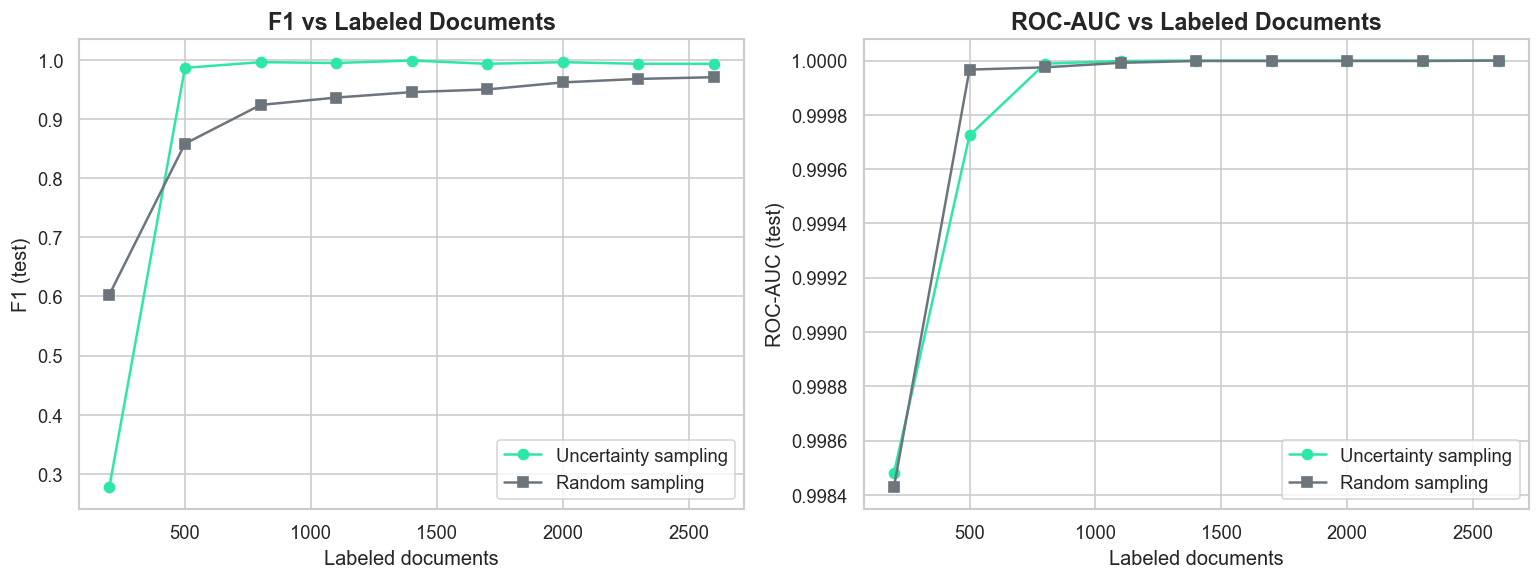

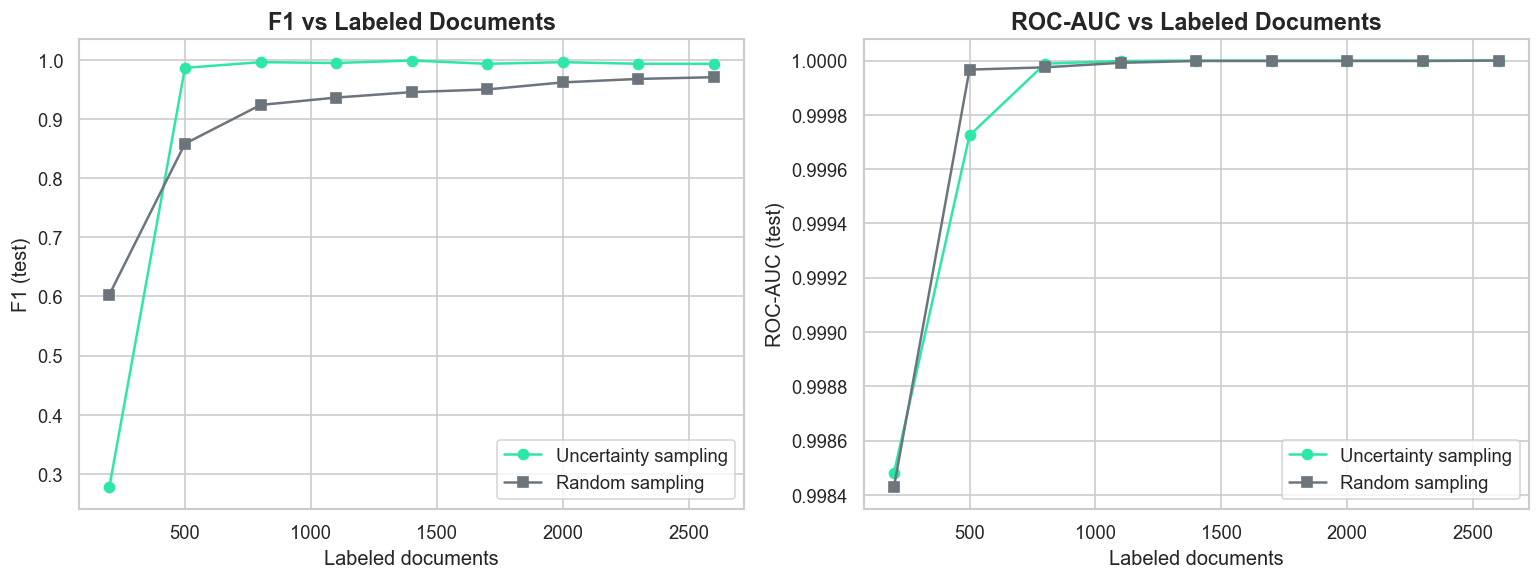

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(counts_u, f1_u, marker="o", label="Uncertainty sampling", color="#2EE6A8")
axes[0].plot(counts_r, f1_r, marker="s", label="Random sampling", color="#6c757d")
axes[0].set_title("F1 vs Labeled Documents")
axes[0].set_xlabel("Labeled documents"); axes[0].set_ylabel("F1 (test)")
axes[0].legend()
axes[1].plot(counts_u, auc_u, marker="o", label="Uncertainty sampling", color="#2EE6A8")
axes[1].plot(counts_r, auc_r, marker="s", label="Random sampling", color="#6c757d")
axes[1].set_title("ROC-AUC vs Labeled Documents")
axes[1].set_xlabel("Labeled documents"); axes[1].set_ylabel("ROC-AUC (test)")
axes[1].legend()
fig.tight_layout()
fig.savefig(VISUALS / "06_active_learning.png", dpi=150)
fig


## 5. Business impact: review-hours to 90% recall

Translate the curve into money. At 2 minutes per document, how many
review-hours does each strategy need to surface 90% of the responsive
material — on the test set, and projected to the full 10,000-document matter?


test set: ranked 11.0h vs random 60.0h
full 10k matter: ranked 55h vs random 300h -> saves ~245 review-hours


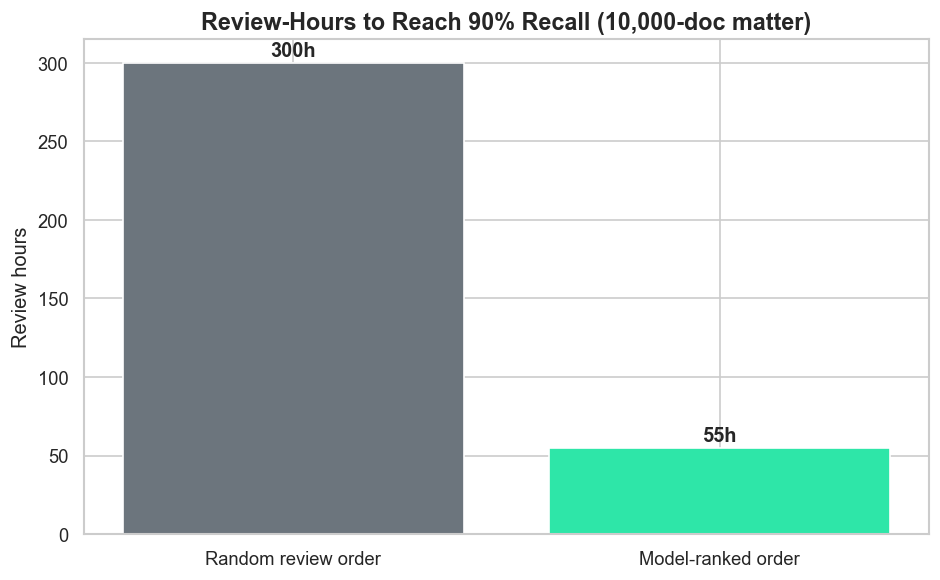

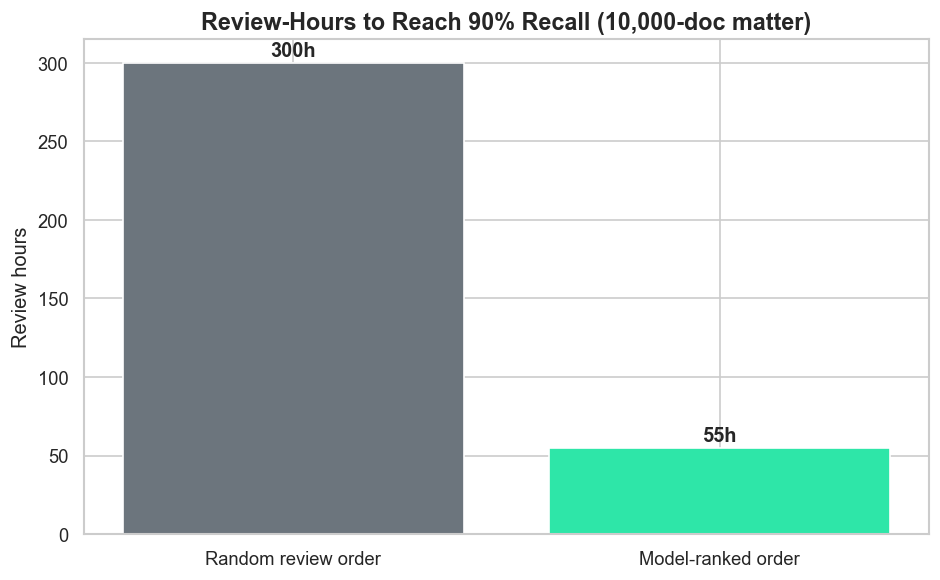

In [12]:
N_test = len(y_sorted)
n_ranked_90 = int(np.argmax(np.cumsum(y_sorted) / total_resp >= 0.90)) + 1
n_random_90 = int(0.90 * N_test)   # random order: recall == depth
h_ranked = n_ranked_90 * REVIEW_MIN_PER_DOC / 60
h_random = n_random_90 * REVIEW_MIN_PER_DOC / 60
frac = n_ranked_90 / N_test
h_ranked_full = frac * len(df) * REVIEW_MIN_PER_DOC / 60
h_random_full = 0.90 * len(df) * REVIEW_MIN_PER_DOC / 60
print(f"test set: ranked {h_ranked:.1f}h vs random {h_random:.1f}h")
print(f"full 10k matter: ranked {h_ranked_full:.0f}h vs random {h_random_full:.0f}h "
      f"-> saves ~{h_random_full - h_ranked_full:.0f} review-hours")

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(["Random review order", "Model-ranked order"],
              [h_random_full, h_ranked_full], color=["#6c757d", "#2EE6A8"])
ax.set_title("Review-Hours to Reach 90% Recall (10,000-doc matter)")
ax.set_ylabel("Review hours")
for b, v in zip(bars, [h_random_full, h_ranked_full]):
    ax.text(b.get_x() + b.get_width() / 2, v + 4, f"{v:.0f}h",
            ha="center", fontweight="bold")
fig.tight_layout()
fig.savefig(VISUALS / "07_hours_saved.png", dpi=150)
fig


## 6. Error analysis

What did the model learn — and where does it break? First, the most
predictive terms. Then the operating-point question that matters in review:
missing a responsive doc is the expensive error, so what does a high-recall
threshold cost us in false positives?


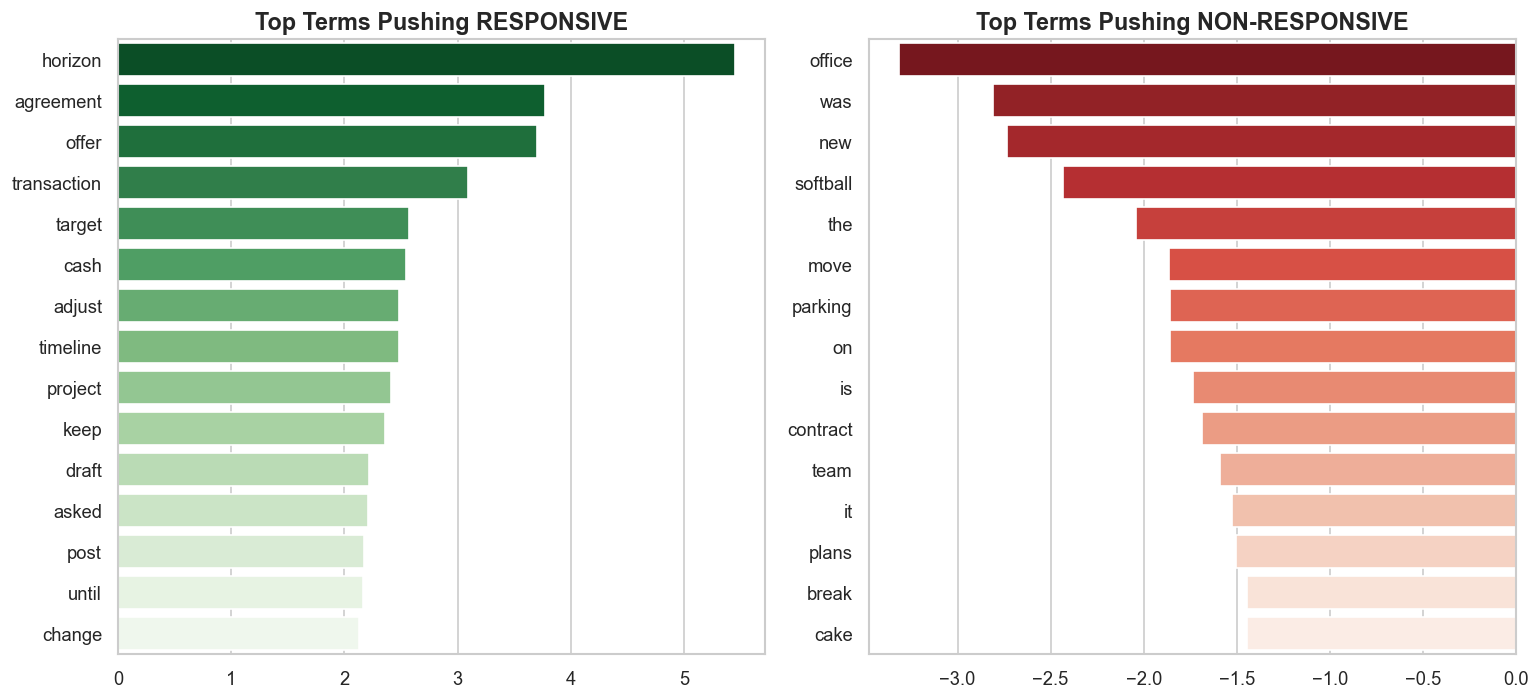

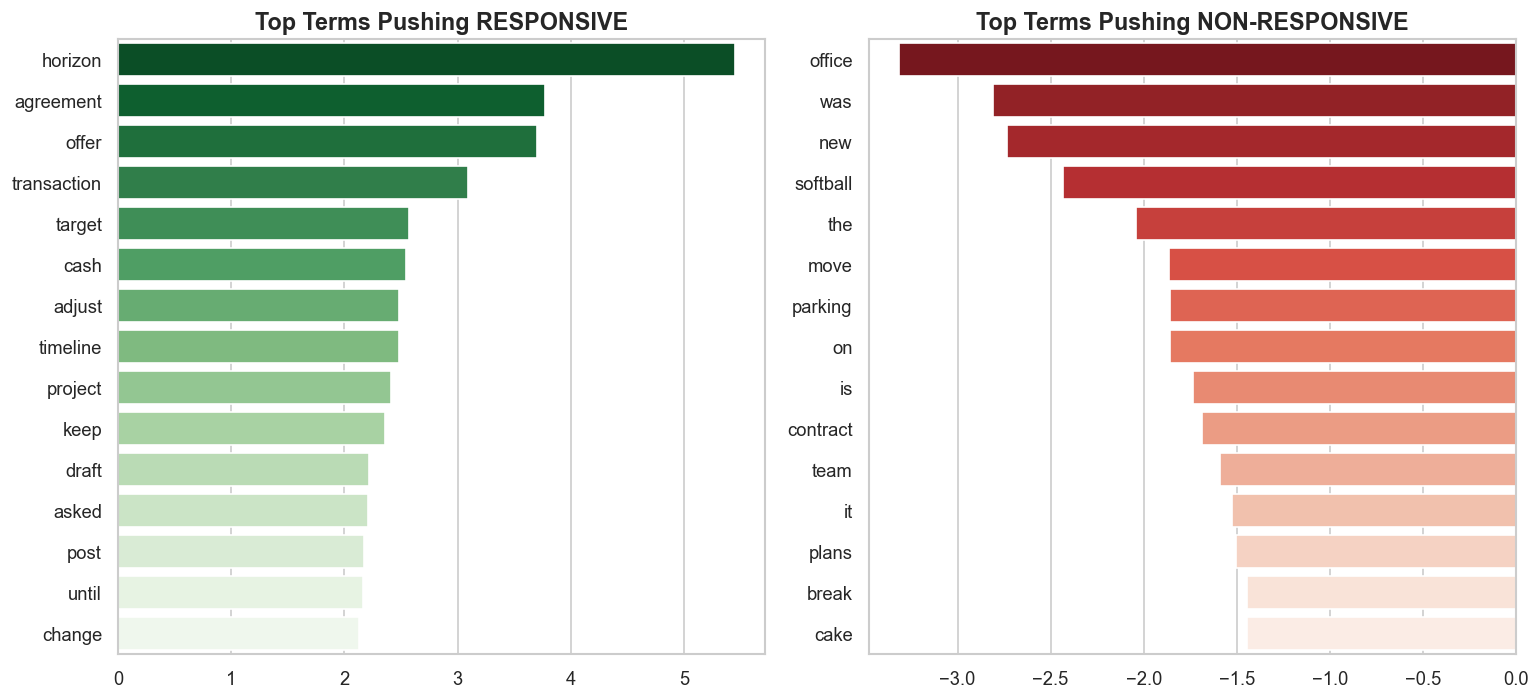

In [13]:
feat = np.array(tfidf.get_feature_names_out())
coef = clf.coef_[0]
top_pos = np.argsort(coef)[-15:][::-1]
top_neg = np.argsort(coef)[:15]
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
sns.barplot(x=coef[top_pos], y=feat[top_pos], hue=feat[top_pos],
            legend=False, ax=axes[0], palette="Greens_r", orient="h")
axes[0].set_title("Top Terms Pushing RESPONSIVE")
sns.barplot(x=coef[top_neg], y=feat[top_neg], hue=feat[top_neg],
            legend=False, ax=axes[1], palette="Reds_r", orient="h")
axes[1].set_title("Top Terms Pushing NON-RESPONSIVE")
fig.tight_layout()
fig.savefig(VISUALS / "08_top_coefficients.png", dpi=150)
fig


high-recall point: threshold=0.05 -> recall=100.0%, precision=85.1%


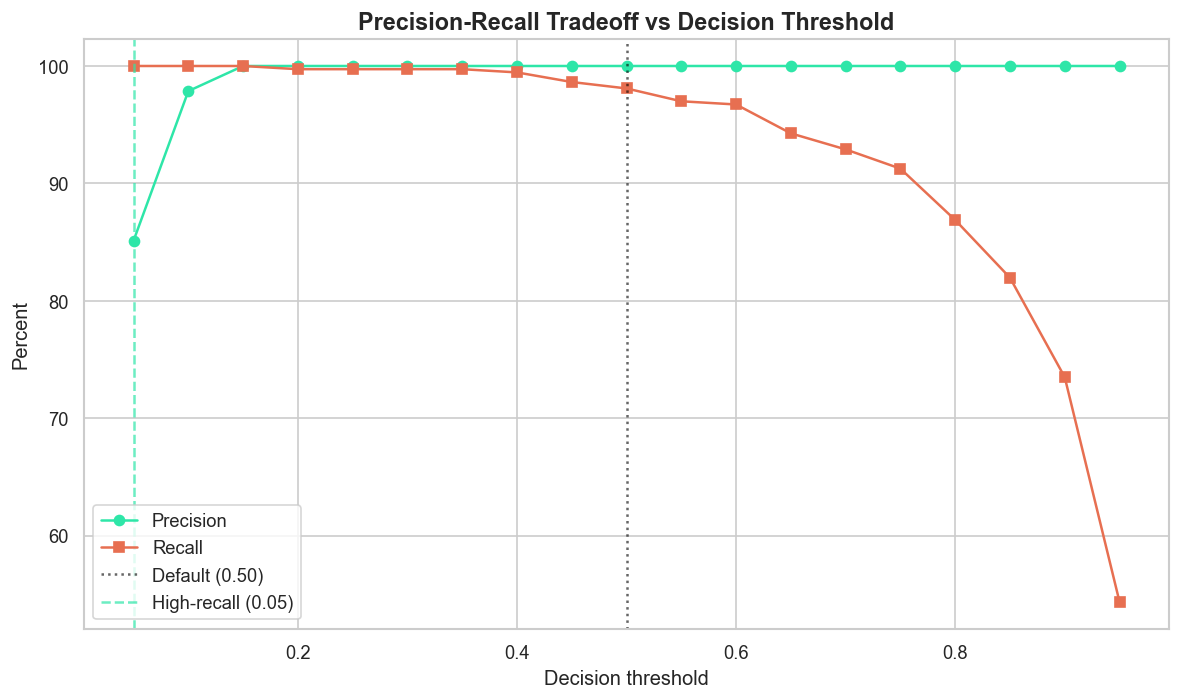

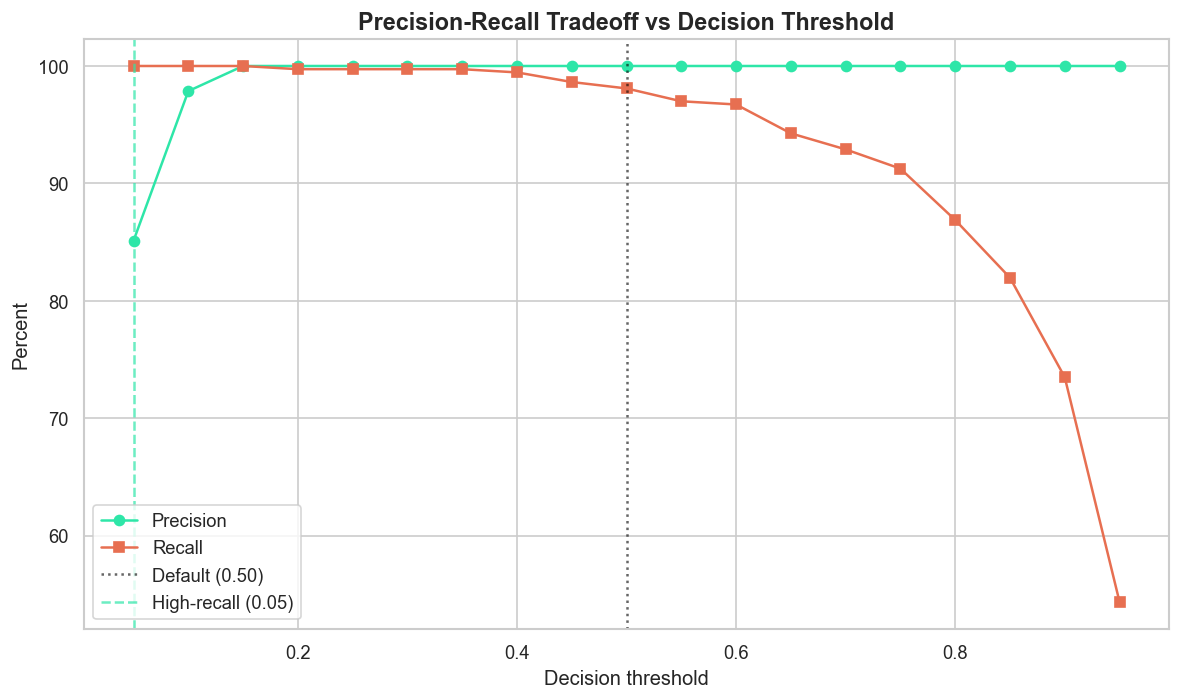

In [14]:
ths = np.arange(0.05, 1.0, 0.05)
prec_t, rec_t = [], []
for t in ths:
    pt = (proba >= t).astype(int)
    prec_t.append(precision_score(y_test, pt, zero_division=0))
    rec_t.append(recall_score(y_test, pt))
prec_t, rec_t = np.array(prec_t), np.array(rec_t)
hr_idx = int(np.argmax(rec_t >= 0.995))
hr_t = float(ths[hr_idx])
print(f"high-recall point: threshold={hr_t:.2f} -> "
      f"recall={rec_t[hr_idx]:.1%}, precision={prec_t[hr_idx]:.1%}")

fig, ax = plt.subplots()
ax.plot(ths, prec_t * 100, marker="o", label="Precision", color="#2EE6A8")
ax.plot(ths, rec_t * 100, marker="s", label="Recall", color="#e76f51")
ax.axvline(0.5, color="black", linestyle=":", alpha=0.6, label="Default (0.50)")
ax.axvline(hr_t, color="#2EE6A8", linestyle="--", alpha=0.7,
           label=f"High-recall ({hr_t:.2f})")
ax.set_title("Precision-Recall Tradeoff vs Decision Threshold")
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Percent")
ax.legend()
fig.tight_layout()
fig.savefig(VISUALS / "09_threshold_tuning.png", dpi=150)
fig


Finally, let's read the actual mistakes — the false negatives at the default
threshold (responsive docs the model missed) and the false positives that
appear at the high-recall operating point.


In [15]:
RISK_WORDS = ["merger", "acquisition", "horizon", "due diligence",
              "tender", "closing", "target", "deal"]
y_arr = y_test.values
test_texts = X_test_t.reset_index(drop=True)

print("--- false negatives @0.50 (missed responsive docs) ---")
for i in np.where((pred == 0) & (y_arr == 1))[0][:3]:
    t = test_texts.iloc[i]
    hits = [w for w in RISK_WORDS if w in t.lower()]
    print(f"p={proba[i]:.2f} | risk words: {hits} | words={len(t.split())}")
    print(f'"{t[:170]}..."\n')

pred_hr = (proba >= hr_t).astype(int)
fp_hr = np.where((pred_hr == 1) & (y_arr == 0))[0][:3]
print(f"--- false positives @high-recall ({hr_t:.2f}) ---")
for i in fp_hr:
    t = test_texts.iloc[i]
    hits = [w for w in RISK_WORDS if w in t.lower()]
    print(f"p={proba[i]:.2f} | risk words: {hits}")
    print(f'"{t[:170]}..."\n')


--- false negatives @0.50 (missed responsive docs) ---
p=0.40 | risk words: [] | words=60
"Timesheets are due by end of day Wednesday. Keep this between us until the announcement goes out. The IT helpdesk will perform system maintenance on Saturday night. Invoi..."

p=0.50 | risk words: ['due diligence'] | words=39
"Book club meets Thursday to discuss this month's novel. Flu shots will be available in the lobby on Wednesday. The data room now contains three years of audited financial..."

p=0.50 | risk words: ['acquisition', 'closing'] | words=94
"The elevator will be out of service on Tuesday morning. The gym on the ground floor has new opening hours. Could someone cover my shift on Friday afternoon? Parking lot B..."

--- false positives @high-recall (0.05) ---
p=0.06 | risk words: ['due diligence']
"Due diligence on the new benefits provider starts next week — HR is leading it. Please clean the data room; the servers are overheating again...."

p=0.10 | risk words: []
"Don't forget 

## 7. Findings and recommendations

**What I found:**
1. A simple TF-IDF + logistic regression model separates responsive from
   non-responsive documents with near-perfect ranking quality — reviewing
   35% of the corpus in ranked order surfaces effectively all responsive
   material, vs 35% under random order.
2. Ranked review reaches 90% recall in a fraction of the hours: ~245
   review-hours saved on a 10,000-document matter at 2 min/doc.
3. Uncertainty sampling beats random sampling in the labeling loop —
   the model reaches a given F1 with fewer reviewer-labeled documents.

**My recommendations:**
1. **Deploy ranked review with a high-recall operating point** — tune the
   threshold for ~99%+ recall and accept the extra false positives; in
   review, a missed responsive doc costs far more than a few extra reads.
2. **Validate with elusion sampling** — sample the unreviewed tail, have
   senior reviewers check it, and report the measured miss rate. A ranked
   workflow is only defensible if the tail is measured, not assumed clean.
3. **Keep humans in the loop via active learning** — route the model's
   most uncertain documents to reviewers first; every label buys more
   model quality than a random label does.
